Use random forest regression to predict the amount of building
materials released from a demolition site.

## Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt


## Data

In [2]:
real_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")
# Switch to select either real or generated data
data = real_data

# Choose features
X = data[["Area", "Volume", "Storeys"]].values
# Set labels
concrete = data[["Concrete"]].values
mineral_wool = data[["Mineral_wool"]].values
metal = data[["Metal"]].values
glass = data[["Glass"]].values


# Hyperparameter optimization

In [3]:
# Replace the argument with {concrete, mineral_wool, glass, metal}
# to select material to predict.
y = np.ravel(concrete)

# Grid search over hyperparameter values
max_depths = range(2,6)
min_samples = range(2,6)
min_leaf_samples = range(2,4)
best_err = np.inf
M = len(y)

for max_depth in max_depths:
   for min_samples_split in min_samples:
      for min_samples_leaf in min_leaf_samples:
         errs = np.zeros(M)
         regr = RandomForestRegressor(
            n_estimators=200,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=2
         )
         # LOO-CV for each HP configuration
         for i in range(M):

            X_tr = np.delete(X, i, 0)
            X_tst = X[i, :]
            y_tr = np.delete(y, i)
            y_tst = y[i]

            regr.fit(X_tr, y_tr)
            y_pred = regr.predict(X_tst.reshape(1,-1))
            err = np.abs(y_pred-y_tst)
            errs[i] = err
         
         mean_err = np.mean(errs)

         if mean_err < best_err:
            best_err = mean_err
            best_max_depth = max_depth
            best_min_samples_split = min_samples_split
            best_min_samples_leaf = min_samples_leaf

print(best_max_depth, best_min_samples_split, best_min_samples_leaf)

4 4 2


# Test runs on varying splits

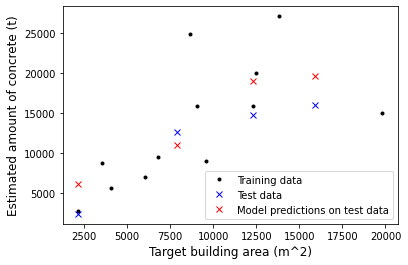

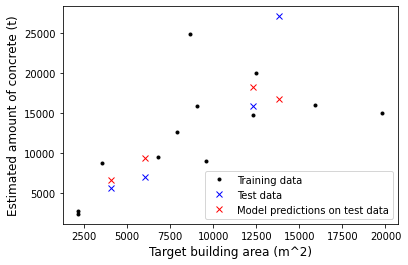

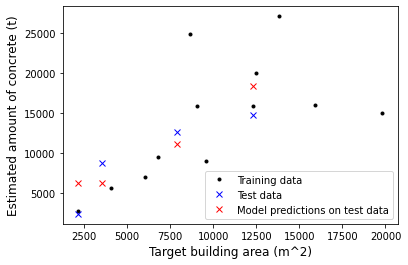

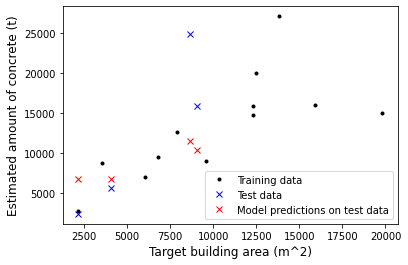

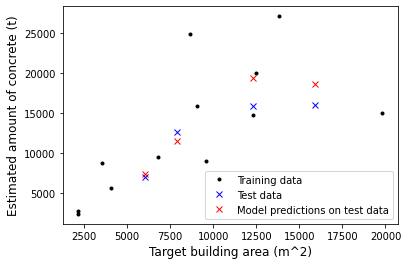

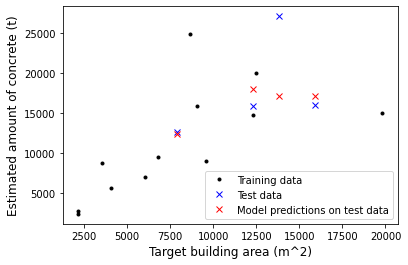

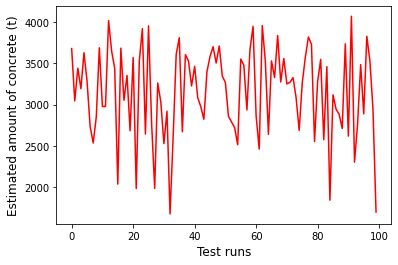

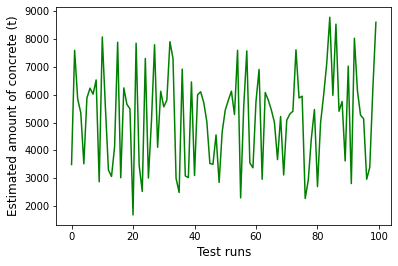

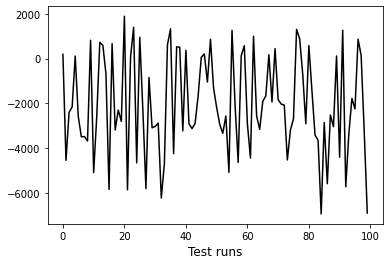

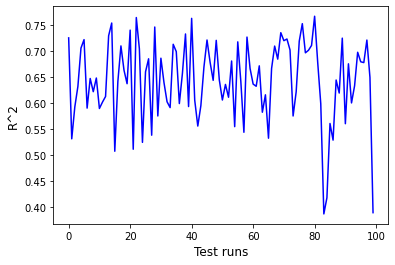

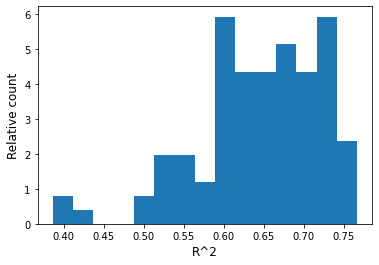

In [4]:
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

n_runs = 100
scores = np.zeros(n_runs)
rs = np.zeros(n_runs)
errs = np.zeros(n_runs)
errs_tr = np.zeros(n_runs)
regr = RandomForestRegressor(
    n_estimators=200,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    max_features=2
)
j = 1

# Print and plot results
for i in range(n_runs):

    X_tr, X_tst, y_tr, y_tst = train_test_split(X, y, test_size=0.2)
    regr.fit(X_tr, y_tr)

    y_pred = regr.predict(X_tst)
    scores[i] = regr.score(X_tst, y_tst)
    errs[i] = np.sqrt(mean_squared_error(y_tst, y_pred))
    errs_tr[i] = np.sqrt(mean_squared_error(y_tr, regr.predict(X_tr)))

    # Compute R^2
    var_pred = np.var(regr.predict(X))
    var_res = np.var(y - regr.predict(X))
    rs[i] = var_pred / (var_pred + var_res)

    if i % 19 == 0:
        plt.figure()
        plt.plot(X_tr[:, 0], y_tr, '.k', label='Training data')
        plt.plot(X_tst[:, 0], y_tst, 'bx', label='Test data')
        plt.plot(X_tst[:, 0], y_pred, 'rx',
                label='Model predictions on test data')
        plt.xlabel('Target building area (m^2)')
        plt.ylabel('Estimated amount of concrete (t)')
        plt.legend()
        plt.savefig(f'../thesis/images/RF_testplot_{j}.PNG')
        j += 1

plt.figure()
plt.plot(errs_tr, 'r-')
plt.xlabel('Test runs')
plt.ylabel('Estimated amount of concrete (t)')
plt.savefig('../thesis/images/RF_diagnostics_tr_err.PNG')

plt.figure()
plt.plot(errs, 'g-')
plt.xlabel('Test runs')
plt.ylabel('Estimated amount of concrete (t)')
plt.savefig('../thesis/images/RF_diagnostics_tst_err.PNG')

plt.figure()
plt.plot(errs_tr - errs, 'k-')
plt.xlabel('Test runs')
plt.savefig('../thesis/images/RF_diagnostics_err_diff.PNG')

plt.figure()
plt.plot(rs, 'b-')
plt.xlabel('Test runs')
plt.ylabel('R^2')
plt.savefig('../thesis/images/RF_diagnostics_rsq.PNG')

plt.figure()
plt.hist(rs, bins=15, density=True)
plt.xlabel('R^2')
plt.ylabel('Relative count')
plt.savefig('../thesis/images/RF_rsq_hist.PNG')
